# Project on Library Management

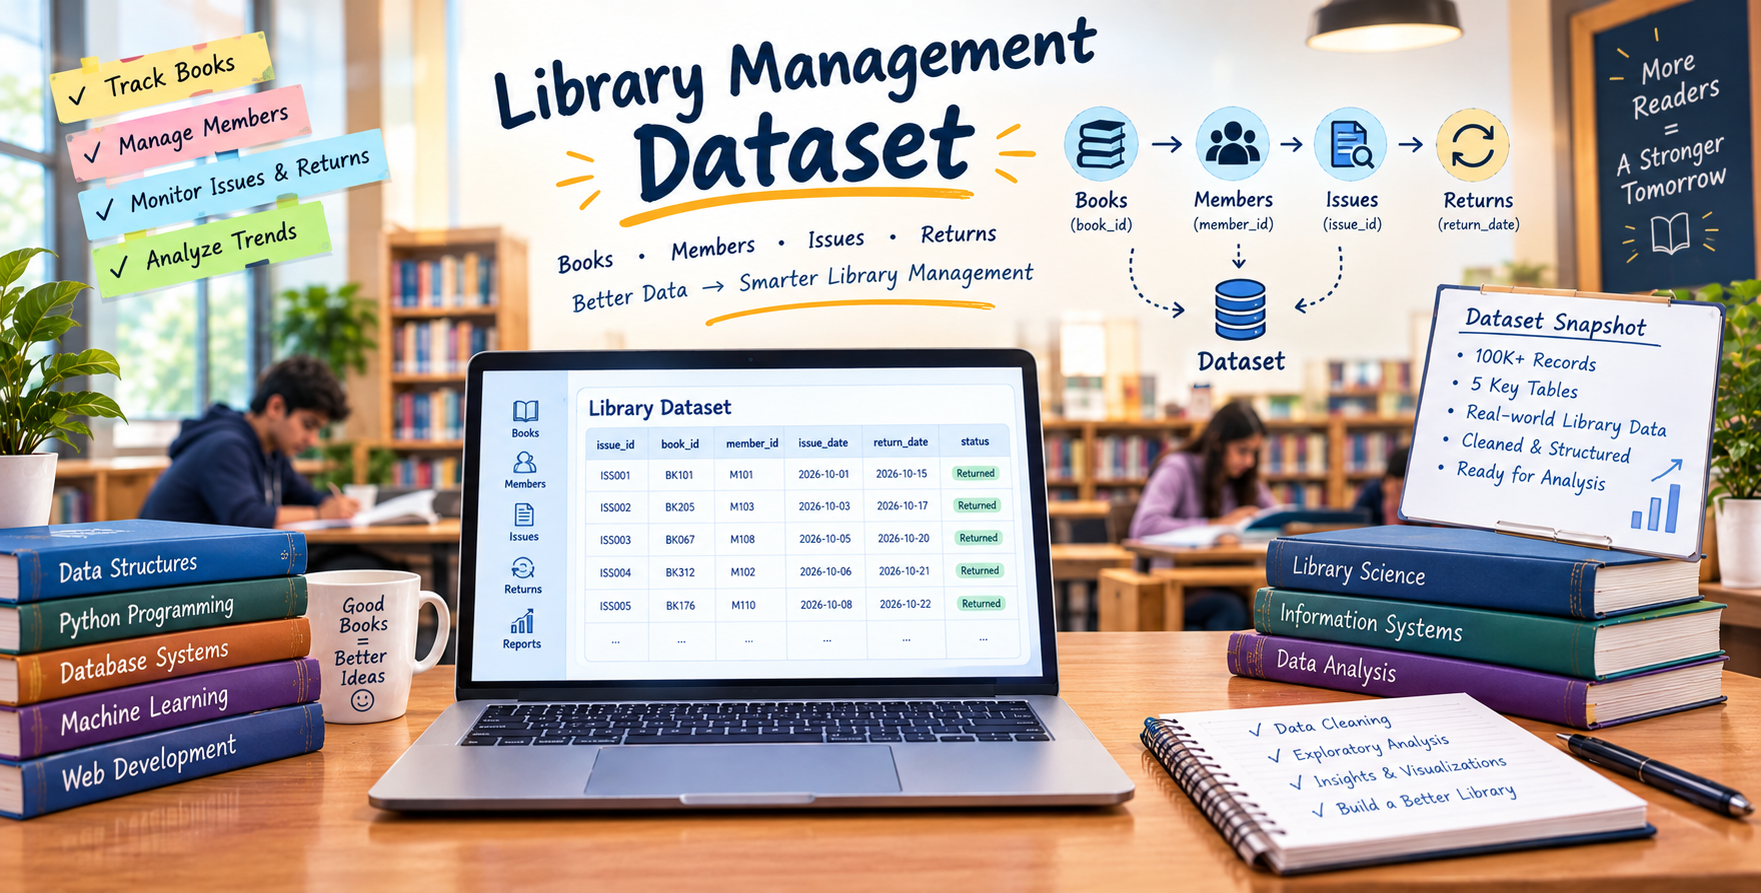

In [25]:
from IPython.display import Image
Image(filename= r"C:\Users\Priyanka\Downloads\ChatGPT Image Oct 2, 2026, 03_30_21 PM.png")

# Dataset Overview

## A school/college wants to know books issued, books available, addition of new book and search a particular book from the whole bank of library. For that they have given the following data: 

* Book_ID → Unique identifier for each book

* Title → Name of the book

* Category → Subject or genre (e.g., Programming, Literature, Science)

* Cabinet → Cabinet number where the book is stored

* Rack → Rack number inside the cabinet

* Row → Row position on the rack

* Timestamp → Date/time of entry or last update

* Status → Availability (e.g., Available, Issued, Reserved) 

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
DATA_PATH = r"C:\Users\Priyanka\Downloads\library_dataset_random-selected-columns.csv"
df = pd.read_csv(DATA_PATH)
df

,Book_ID,Title,Category,Cabinet,Rack,Row,Timestamp,Status
0,B001,The Adventures of Chronicles,Programming,4,5,4,2024-12-11 10:01:00,Present
1,B002,The Dream of Shadows,History,3,3,5,2024-12-11 10:02:00,Missing
2,B003,The Shadows of Mystery,Science,5,3,4,2024-12-11 10:03:00,Checked Out
3,B004,The Chronicles of Dream,Fiction,4,1,1,2024-12-11 10:04:00,Missing
4,B005,The Future of Adventures,Programming,3,4,2,2024-12-11 10:05:00,Missing
...,...,...,...,...,...,...,...,...
195,B196,The Journey of Journey,Programming,4,1,1,2024-12-11 13:16:00,Checked Out
196,B197,The Future of Adventures,Thriller,3,4,5,2024-12-11 13:17:00,Missing
197,B198,The Chronicles of Quest,Thriller,4,1,4,2024-12-11 13:18:00,Present
198,B199,The Journey of Adventures,History,2,1,1,2024-12-11 13:19:00,Present


In [3]:
df.head()

,Book_ID,Title,Category,Cabinet,Rack,Row,Timestamp,Status
0,B001,The Adventures of Chronicles,Programming,4,5,4,2024-12-11 10:01:00,Present
1,B002,The Dream of Shadows,History,3,3,5,2024-12-11 10:02:00,Missing
2,B003,The Shadows of Mystery,Science,5,3,4,2024-12-11 10:03:00,Checked Out
3,B004,The Chronicles of Dream,Fiction,4,1,1,2024-12-11 10:04:00,Missing
4,B005,The Future of Adventures,Programming,3,4,2,2024-12-11 10:05:00,Missing


In [4]:
df.tail(10)

,Book_ID,Title,Category,Cabinet,Rack,Row,Timestamp,Status
190,B191,The Dream of Dream,Programming,1,5,2,2024-12-11 13:11:00,Missing
191,B192,The Journey of Mystery,History,2,5,5,2024-12-11 13:12:00,Checked Out
192,B193,The Code of Shadows,Science,3,2,3,2024-12-11 13:13:00,Present
193,B194,The Dream of Shadows,Fiction,3,4,3,2024-12-11 13:14:00,Present
194,B195,The Chronicles of Journey,Science,2,1,4,2024-12-11 13:15:00,Checked Out
195,B196,The Journey of Journey,Programming,4,1,1,2024-12-11 13:16:00,Checked Out
196,B197,The Future of Adventures,Thriller,3,4,5,2024-12-11 13:17:00,Missing
197,B198,The Chronicles of Quest,Thriller,4,1,4,2024-12-11 13:18:00,Present
198,B199,The Journey of Adventures,History,2,1,1,2024-12-11 13:19:00,Present
199,B200,The Dream of Code,Fiction,5,1,5,2024-12-11 13:20:00,Checked Out


In [5]:
df.shape

(200, 8)

# Content of data

In [6]:
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Book_ID    200 non-null    str  
 1   Title      200 non-null    str  
 2   Category   200 non-null    str  
 3   Cabinet    200 non-null    int64
 4   Rack       200 non-null    int64
 5   Row        200 non-null    int64
 6   Timestamp  200 non-null    str  
 7   Status     200 non-null    str  
dtypes: int64(3), str(5)
memory usage: 24.6 KB


In [7]:
df.isna().sum()

Book_ID      0
Title        0
Category     0
Cabinet      0
Rack         0
Row          0
Timestamp    0
Status       0
dtype: int64

In [8]:

df.columns

Index(['Book_ID', 'Title', 'Category', 'Cabinet', 'Rack', 'Row', 'Timestamp',
       'Status'],
      dtype='str')

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Cabinet,200.0,3.16,1.354093,1.0,2.0,3.0,4.0,5.0
Rack,200.0,2.96,1.469420,1.0,2.0,3.0,4.0,5.0
Row,200.0,2.96,1.377639,1.0,2.0,3.0,4.0,5.0


In [10]:
df.Book_ID.describe()

count      200
unique     200
top       B001
freq         1
Name: Book_ID, dtype: object

In [11]:
df.duplicated().value_counts()

False    200
Name: count, dtype: int64

###### Duplicate check: if the count shows only False, the dataset has no duplicate rows.

In [12]:
df.duplicated(subset=['Book_ID']).value_counts()

False    200
Name: count, dtype: int64

##### If only False is shown, every Book_ID is unique.

# Data information and preprocessing

###  1. Add a new book

In [13]:
def add_book(book_dict):
    global df
    if book_dict["Book_ID"] in df["Book_ID"].values:
        print("Book already exists.")
    else:
        df = pd.concat([df, pd.DataFrame([book_dict])], ignore_index=True)
        print(f"Book {book_dict['Book_ID']} added.")

In [14]:
new_book = {"Book_ID": "B001","Title": "Python Basics","Category": "Programming","Cabinet": "C1","Rack": "R2","Row": "Row3","Timestamp": "2026-10-02","Status": "Available"
}
add_book(new_book)

Book already exists.


### 2. Search for a book

In [15]:
def search_book(book_id):
    result = df[df["Book_ID"] == book_id]
    if not result.empty:
        print(result)
    else:
        print("Book not found.")

search_book("B001")

  Book_ID                         Title     Category  Cabinet  Rack  Row  \
0    B001  The Adventures of Chronicles  Programming        4     5    4   

             Timestamp   Status  
0  2024-12-11 10:01:00  Present  


### 3. Issue a book (update status)

In [16]:
def issue_book(book_id):
    if book_id in df["Book_ID"].values:
        df.loc[df["Book_ID"] == book_id, "Status"] = "Issued"
        print(f"Book {book_id} has been issued.")
    else:
        print("Book not found.")

issue_book("B001")

Book B001 has been issued.


### 4. Return a book (mark as Available)

In [19]:
def return_book(book_id):
    if book_id in df["Book_ID"].values:
        df.loc[df["Book_ID"] == book_id, "Status"] = "Available"
        print(f"Book {book_id} has been returned and marked as available.")
    else:
        print("Book not found.")

In [20]:
return_book("B001")

Book B001 has been returned and marked as available.


### 5. Display all available books

In [23]:
def display_available_books():
    available = df[df["Status"] == "Available"]
    if not available.empty:
        print(available)
    else:
        print("No books are currently available.")

display_available_books()

  Book_ID                         Title     Category  Cabinet  Rack  Row  \
0    B001  The Adventures of Chronicles  Programming        4     5    4   

             Timestamp     Status  
0  2024-12-11 10:01:00  Available  


### 6. Save updated records

In [24]:
def save_records(filename="library_updated.csv"):
    df.to_csv(filename, index=False)
    print(f"Library records saved to {filename}")

save_records()

Library records saved to library_updated.csv


# Reference

#### Kaggle: https://www.kaggle.com/datasets/ziya07/library-management